# pyNISAR: quad-polarization tutorial

A real 5 × 5 km example, from NASA search to saved products. Run the cells in order.

The source repository is private: download the source ZIP and notebook with your GitHub account. Upload both to Jupyter/CryoCloud or Colab; rename the ZIP `pynisar_source.zip`. NASA Earthdata credentials are required. The two examples use the same quad acquisition for a controlled comparison of channel selections.

## Step 1 — Install pyNISAR

Place the private source ZIP beside this notebook and name it `pynisar_source.zip`. This installs the library in your current Python environment.

In [ ]:
%pip install ./pynisar_source.zip

## Step 2 — Import libraries

Earthdata is NASA's account service; earthaccess connects Python to its data catalogue and protected files.

In [2]:
import earthaccess
import pynisar
import pandas as pd
from IPython.display import display, Image

## Step 3 — Define the study area

Create a 5 × 5 km square in the western Great Lakes. Coordinates are longitude, latitude. To use your own polygon instead: `area = "study_area.geojson"`.

In [3]:
area = pynisar.square_aoi(-90.2, 46.45, size_km=5)
area.to_file("study_area.geojson", driver="GeoJSON")
area

,name,geometry
0,5 km study square,"POLYGON ((-90.16865 46.42673, -90.16632 46.471..."


## Step 4 — Sign in to NASA Earthdata

Use your own Earthdata account. Never include a password or token in a shared notebook.

In [4]:
auth = earthaccess.login(persist=False)
print("NASA login successful:", auth.authenticated)

NASA login successful: True


## Step 5 — Search NISAR scenes

Search provisional GCOV data covering the square. We select quad acquisitions so both examples can use the same measured observation; the dual example uses only HH and HV. The catalogue filter is checked against actual channels during processing.

In [5]:
scenes = pynisar.find_scenes(
    product="GCOV", aoi=area,
    start="2025-11-06", end="2025-11-18",
    polarization="quad",
)
pynisar.scene_table(scenes).head(6)

/srv/conda/envs/notebook/lib/python3.14/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


,scene,acquired_utc,collection
0,NISAR_L2_PR_GCOV_004_113_D_065_2005_QPDH_A_202...,2025-11-06T01:05:37.000000Z,NISAR_L2_GCOV_PROVISIONAL_V1
1,NISAR_L2_PR_GCOV_005_113_D_065_2005_QPDH_A_202...,2025-11-18T01:05:38.000000Z,NISAR_L2_GCOV_PROVISIONAL_V1


## Step 6 — Map the search results

The orange square is the study area. Outline labels match the table row numbers.

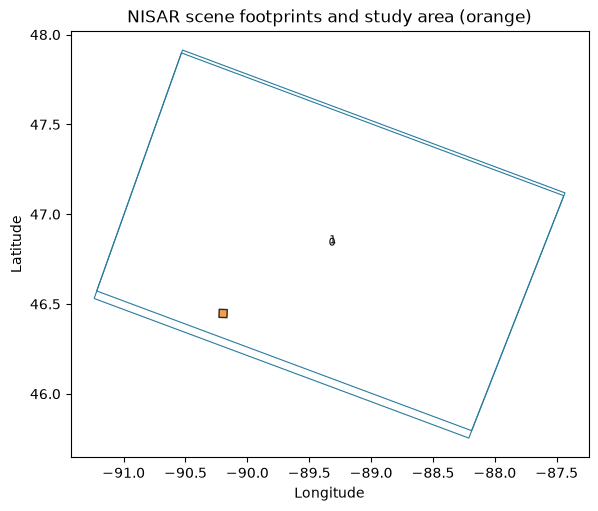

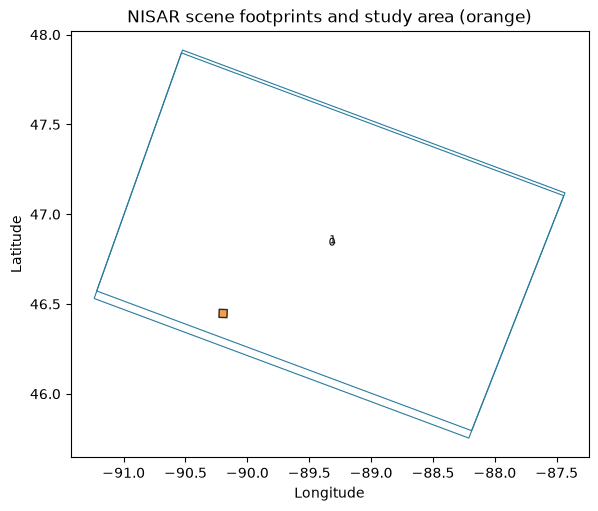

In [6]:
search_map = pynisar.plot_search(scenes, area)
search_map.savefig("search_map.png", dpi=160)
search_map

## Step 7 — Select one scene

Choose row 0, the first scene in the table. Change 0 to another row number to choose a different observation. Only this scene is processed.

In [7]:
scene = scenes[0]
pynisar.scene_table([scene])

,scene,acquired_utc,collection
0,NISAR_L2_PR_GCOV_004_113_D_065_2005_QPDH_A_202...,2025-11-06T01:05:37.000000Z,NISAR_L2_GCOV_PROVISIONAL_V1


## Step 8 — Generate polarimetric products

Read the pixels covering the square and save the metric GeoTIFFs, statistics and manifest. No full HDF5 is downloaded. Remote reads have a 512 MiB cap. Quad metrics explicitly assume reciprocity.

In [8]:
run = pynisar.process_scene(
    scene, "outputs/quad",
    aoi=area, channels=["HH", "HV", "VH", "VV"],
    reciprocal=True,
    max_mb=512,
)
print("Products saved in:", run)

Products saved in: outputs/quad/case-gcov-573e04559bb3499ca1529e675722cd5e


## Step 9 — Inspect the outputs

The table contains statistics computed from this run; it is not a fabricated example.

In [9]:
statistics = pd.read_csv(run / "statistics.csv")
statistics.head(6)

,metric,count,finite_fraction,min,median,mean,max,std
0,HH,62500,0.992048,0.003431,0.306982,0.349370,71.593750,0.444707
1,HV,62500,0.992048,0.001650,0.071817,0.078140,10.512817,0.072998
2,VH,62500,0.992048,0.001775,0.073969,0.080842,11.680298,0.078365
3,VV,62500,0.992048,0.003216,0.218029,0.245087,33.966309,0.244927
4,HV_reciprocal,62500,0.992048,0.000516,0.029966,0.032714,4.725319,0.031374
5,span,62500,0.992048,0.015545,0.623450,0.659885,105.736696,0.673891


## Step 10 — Show the figures

Display HH and HV power, followed by the polarimetric diagram. Figures come from the products generated above.

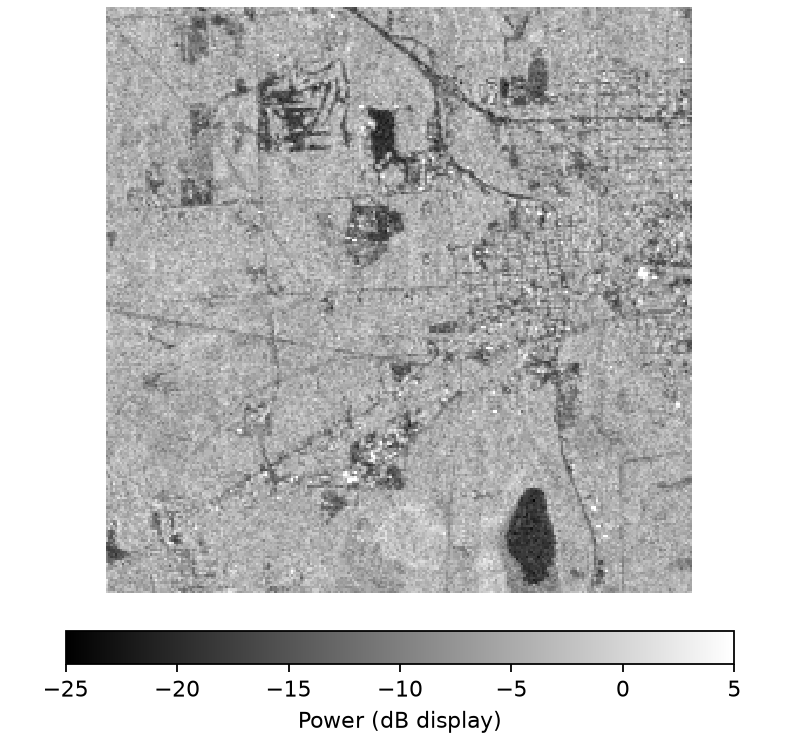

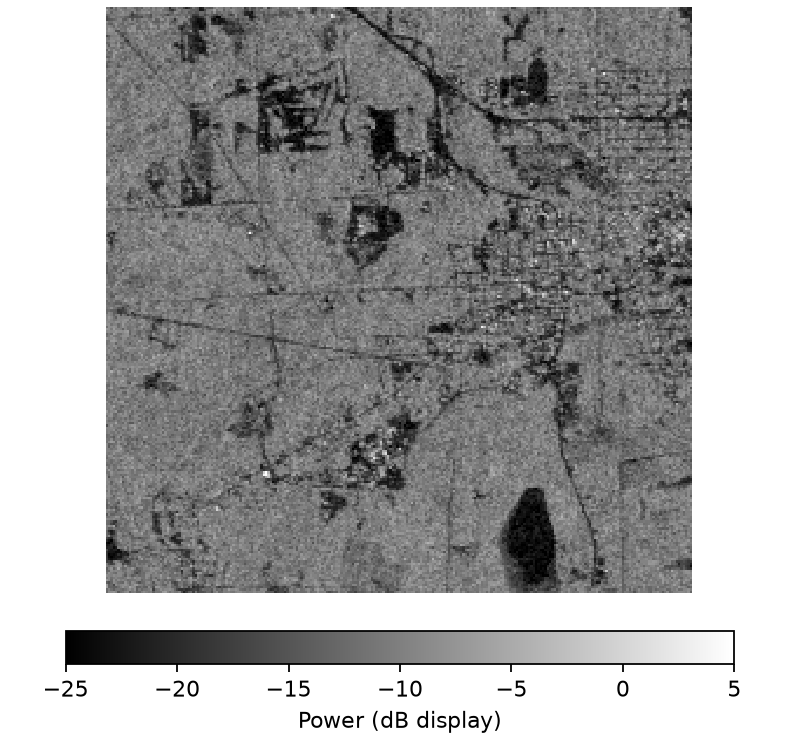

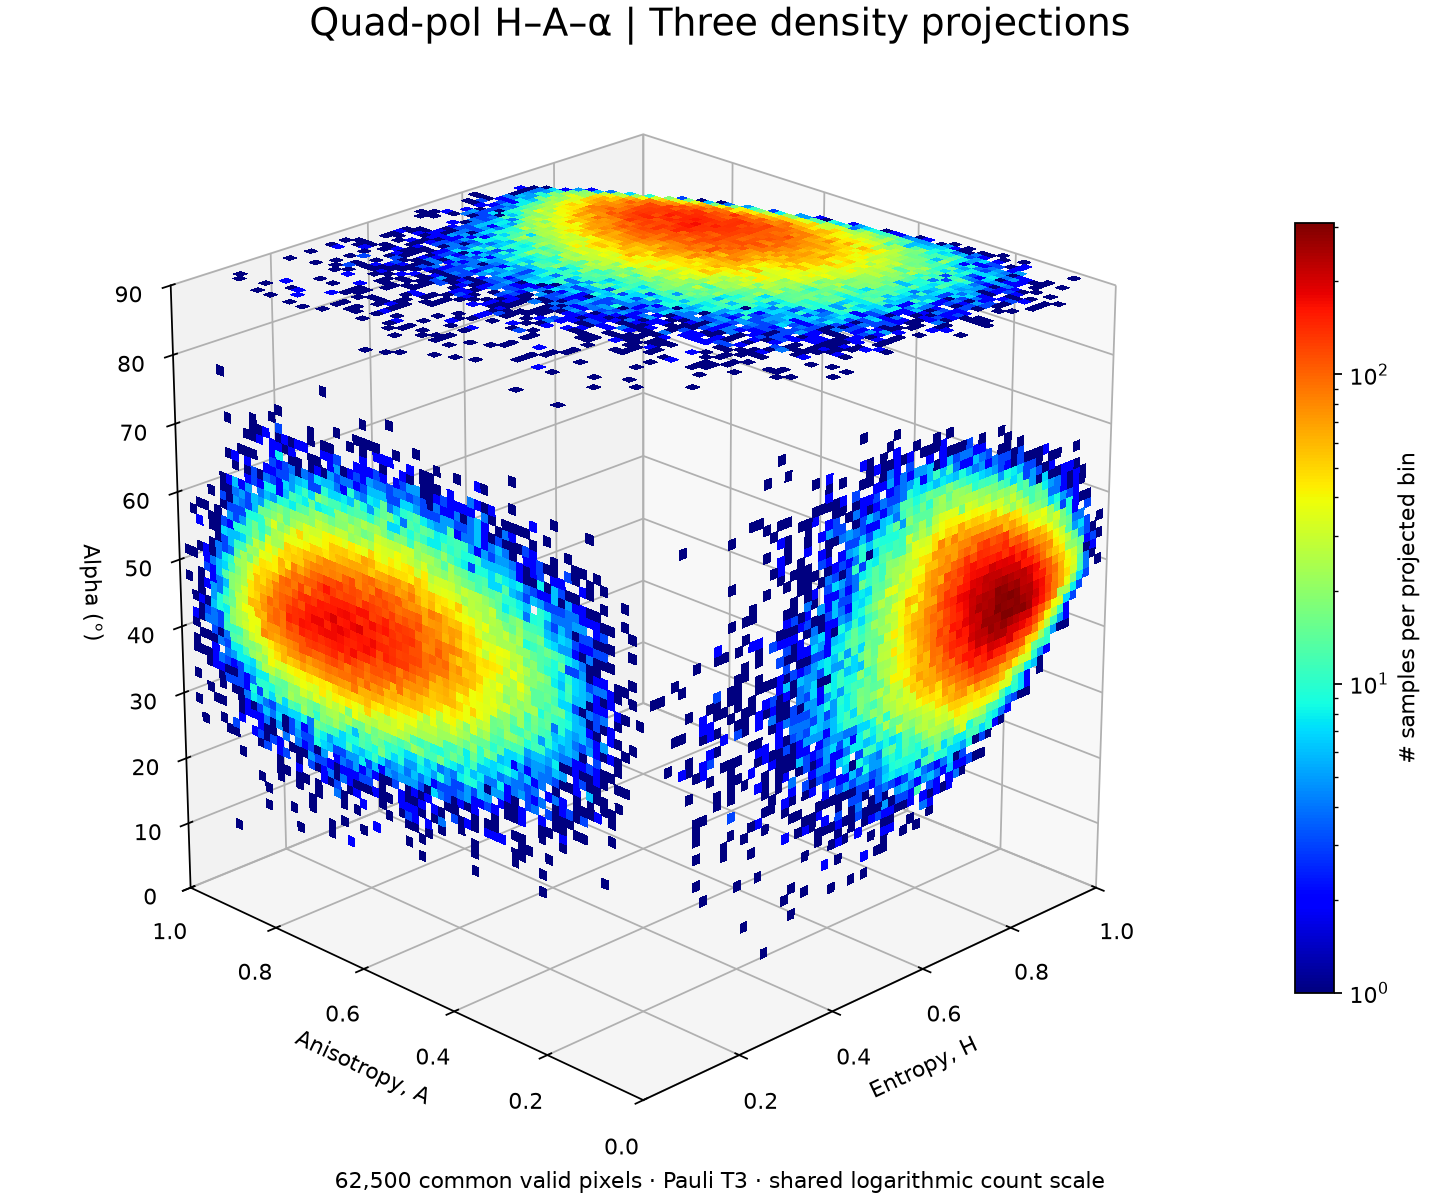

In [10]:
figures = pynisar.plot_gallery(run)
display(Image(filename=str(figures[0])))
display(Image(filename=str(figures[1])))
display(Image(filename=str(figures[2])))

## Step 11 — Record the environment

Keep these versions with your executed notebook. Execution platform and date document this tutorial, not the manuscript processing.

In [11]:
import sys
import platform
from datetime import datetime, timezone
from importlib.metadata import version

print("Executed UTC:", datetime.now(timezone.utc).isoformat())
print("Python:", sys.version.split()[0])
print("System:", platform.system())
print("pyNISAR:", pynisar.__version__)
print("earthaccess:", version("earthaccess"))

Executed UTC: 2026-09-28T15:39:29.502517+00:00
Python: 3.14.7
System: Linux
pyNISAR: 0.1.0a1
earthaccess: 0.18.0
